<a href="https://colab.research.google.com/github/jashwanthnaiknenavath83-jpg/solar-project-finance-model-germany/blob/main/notebooks/01_solar_project_finance_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 50 MW Solar PV Project Finance Model (Germany)
Project finance model with Monte Carlo risk analysis.

**Status:** all inputs are placeholder assumptions, to be replaced with sourced values (PVGIS, SMARD, industry cost reports).

Run the notebook with **Runtime → Run all**. Cells must stay in this order.

In [1]:
!pip install numpy-financial -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf
from scipy.optimize import brentq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 3.5 MB/s eta 0:00:00


## 1. Financial model
One function that runs the full model: generation, revenue, tax, debt sized to a target DSCR, equity cash flows, IRRs and LCOE.

In [2]:
def run_model(price=70, yield_kwh=1000, capex_mw=600_000, interest=0.05,
              capacity_mw=50, opex_mw=12_000, degradation=0.004, life=25,
              tax_rate=0.30, dep_years=20, target_dscr=1.25, tenor=18,
              max_gearing=0.75, discount_rate=0.07):
    years = np.arange(1, life + 1)
    capex = capacity_mw * capex_mw
    gen = capacity_mw * yield_kwh * (1 - degradation) ** (years - 1)
    ebitda = gen * price - capacity_mw * opex_mw
    dep = np.where(years <= dep_years, capex / dep_years, 0)
    ebit = ebitda - dep
    cfads = ebitda - np.maximum(ebit, 0) * tax_rate
    ds_cap = np.where(years <= tenor, cfads / target_dscr, 0)
    debt_sculpted = npf.npv(interest, np.concatenate(([0], ds_cap)))
    debt = max(min(debt_sculpted, max_gearing * capex), 0)
    ds = ds_cap * (debt / debt_sculpted) if debt_sculpted > 0 else ds_cap * 0
    bal, ip = debt, []
    for t in range(life):
        i = bal * interest
        ip.append(i)
        bal -= ds[t] - i
    ip = np.array(ip)
    tax_lev = np.maximum(ebit - ip, 0) * tax_rate
    eq_cf = ebitda - tax_lev - ds
    eq_flows = np.concatenate(([-(capex - debt)], eq_cf))
    paying = ds > 0
    dscr = cfads[paying] / ds[paying] if paying.any() else np.array([np.nan])
    proj_irr = npf.irr(np.concatenate(([-capex], cfads)))
    opex_arr = np.full(life, capacity_mw * opex_mw)
    disc = (1 + discount_rate) ** years
    lcoe = (capex + (opex_arr / disc).sum()) / (gen / disc).sum()
    return {"project_irr_post_tax": proj_irr, "equity_irr": npf.irr(eq_flows),
            "debt": debt, "gearing": debt / capex,
            "min_dscr": dscr.min(), "avg_dscr": dscr.mean(), "lcoe": lcoe}

## 2. Base case (70 EUR/MWh merchant price)

In [3]:
base = run_model()
print(f"Project IRR (post-tax): {base['project_irr_post_tax']:.2%}")
print(f"Equity IRR:             {base['equity_irr']:.2%}")
print(f"Gearing:                {base['gearing']:.0%}")
print(f"Min DSCR:               {base['min_dscr']:.2f}x")
print(f"LCOE:                   {base['lcoe']:.1f} EUR/MWh")

Project IRR (post-tax): 6.00%
Equity IRR:             10.36%
Gearing:                75%
Min DSCR:               1.25x
LCOE:                   65.7 EUR/MWh


## 3. Sensitivity: equity IRR vs. power price

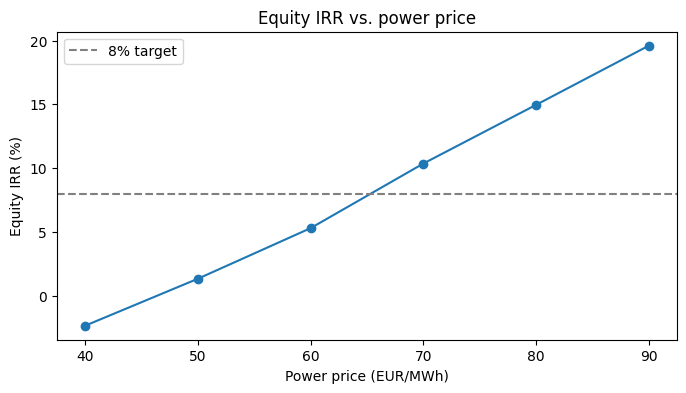

Break-even price for 8% equity IRR: 65.9 EUR/MWh


In [4]:
prices = [40, 50, 60, 70, 80, 90]
irrs = [run_model(price=p)["equity_irr"] * 100 for p in prices]

plt.figure(figsize=(8, 4))
plt.plot(prices, irrs, marker="o")
plt.axhline(8, color="grey", linestyle="--", label="8% target")
plt.title("Equity IRR vs. power price")
plt.xlabel("Power price (EUR/MWh)")
plt.ylabel("Equity IRR (%)")
plt.legend()
plt.show()

breakeven = brentq(lambda p: run_model(price=p)["equity_irr"] - 0.08, 55, 75)
print(f"Break-even price for 8% equity IRR: {breakeven:.1f} EUR/MWh")

## 4. Monte Carlo simulation
3,000 runs with random price, yield, CAPEX and interest rate.
The spreads are assumptions and should be justified with data (SMARD prices, PVGIS yield range).

In [5]:
rng = np.random.default_rng(42)
N = 3000

price    = np.clip(rng.normal(70, 12, N), 20, None)
yld      = rng.normal(1000, 50, N)
capex_mw = rng.normal(600_000, 30_000, N)
interest = np.clip(rng.normal(0.05, 0.005, N), 0.02, None)

rows = []
for i in range(N):
    r = run_model(price=price[i], yield_kwh=yld[i],
                  capex_mw=capex_mw[i], interest=interest[i])
    rows.append({"price": price[i], "yield": yld[i],
                 "capex_mw": capex_mw[i], "interest": interest[i],
                 "equity_irr": r["equity_irr"], "gearing": r["gearing"]})

mc = pd.DataFrame(rows)
e = mc["equity_irr"]

print(f"Mean equity IRR:      {e.mean():.2%}")
print(f"P10 (bad case):       {e.quantile(0.10):.2%}")
print(f"P50 (median):         {e.quantile(0.50):.2%}")
print(f"P90 (good case):      {e.quantile(0.90):.2%}")
print(f"Chance IRR >= 8%:     {(e >= 0.08).mean():.0%}")
print(f"Chance IRR < 0%:      {(e < 0).mean():.1%}")

Mean equity IRR:      10.22%
P10 (bad case):       2.63%
P50 (median):         10.21%
P90 (good case):      18.05%
Chance IRR >= 8%:     62%
Chance IRR < 0%:      3.3%


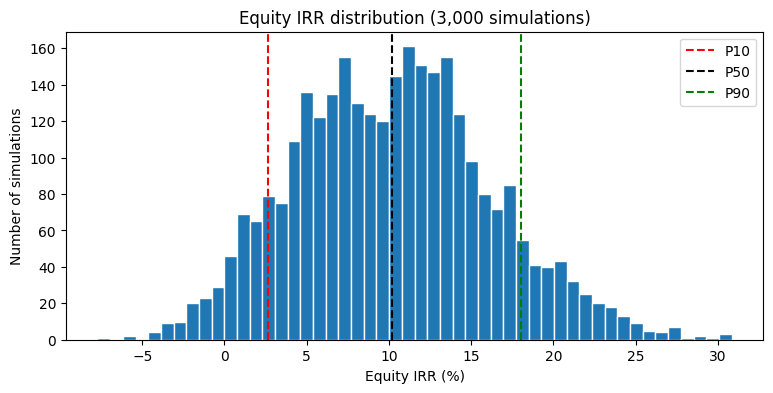

In [6]:
plt.figure(figsize=(9, 4))
plt.hist(e * 100, bins=50, edgecolor="white")
plt.axvline(e.quantile(0.10) * 100, color="red", linestyle="--", label="P10")
plt.axvline(e.quantile(0.50) * 100, color="black", linestyle="--", label="P50")
plt.axvline(e.quantile(0.90) * 100, color="green", linestyle="--", label="P90")
plt.title("Equity IRR distribution (3,000 simulations)")
plt.xlabel("Equity IRR (%)")
plt.ylabel("Number of simulations")
plt.legend()
plt.show()

## 5. Which risk matters most?

price       0.92
yield       0.26
capex_mw   -0.23
interest   -0.10
dtype: float64


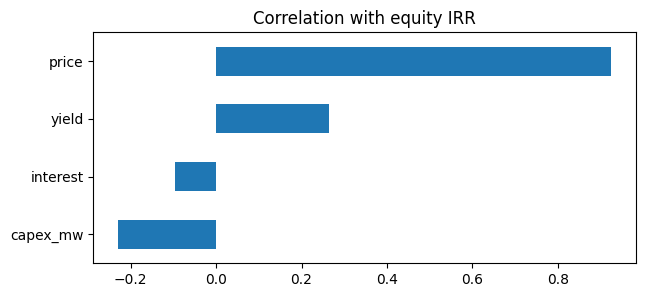

In [7]:
corr = mc[["price", "yield", "capex_mw", "interest"]].corrwith(mc["equity_irr"])
print(corr.round(2))

corr.sort_values().plot(kind="barh", figsize=(7, 3),
                        title="Correlation with equity IRR")
plt.show()

## 6. Key findings and limitations
**Findings:** (- Base case (70 EUR/MWh): equity IRR 10.4% vs. post-tax project IRR 6.0%
- Break-even price for an 8% equity IRR: about 65.9 EUR/MWh, close to the LCOE of 65.7
- Monte Carlo: median equity IRR about 10.2%, with a P10-P90 range of 2.6% to 18.1%
- 62% chance of reaching 8% equity IRR, 3.3% chance of a negative return
- Price is the dominant risk factor (correlation 0.92)
- Leverage raises equity IRR only if project IRR exceeds the cost of debt)


**Limitations:**
- Flat price, no inflation or price curve
- No loss carry-forward, reserve accounts or construction period
- Debt is re-sized in every run, so DSCR does not show default risk
- Input distributions are assumptions, not fitted to data